In [1]:
import sys
import os

parent = os.path.dirname(os.path.realpath("../"))
sys.path.append(parent)

import numpy as np
import scipy
import tqdm
import matplotlib.pyplot as plt
import glob


from musik import *
from utils import geometry

os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import open3d as o3d
from utils import phantom_builder

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


# Make Phantom

In [2]:
voxel_size = np.array([0.001, 0.001, 0.001])
# voxel_size = np.array([0.0005, 0.0005, 0.0005])
surface_mesh = o3d.io.read_triangle_mesh(
    f"{parent}/assets/cardiac_TEE_phantom/esophageal_surface.ply"
)
body_mask = phantom_builder.voxelize(voxel_size[0], mesh=surface_mesh)

In [3]:
test_phantom = phantom.Phantom(
    voxel_dims=(voxel_size[0], voxel_size[0], voxel_size[0]),
    matrix_dims=body_mask.shape,
    baseline=(1540, 1000),
    seed=None,
)

blood = tissue.Tissue(name="blood", c=1578, rho=1060, sigma=1.3, scale=0.00001, label=1)
myocardium = tissue.Tissue(
    name="myocardium", c=1592, rho=1081, sigma=20, scale=0.0001, label=2
)
esophagus = tissue.Tissue(
    name="esophagus", c=1500, rho=1100, sigma=10, scale=0.0001, label=3
)
fat = tissue.Tissue(name="fat", c=1480, rho=970, sigma=15, scale=0.0001, label=4)

heart_file_dir = f"{parent}/assets/cardiac_TEE_phantom"

heart_tissue_list = [blood, myocardium, esophagus]

test_phantom.build_organ_from_mesh(
    surface_mesh, voxel_size[0], heart_tissue_list, dir_path=heart_file_dir
)
test_phantom.set_default_tissue(fat)

Added blood
Added myocardium
Added esophagus


In [4]:
test = test_phantom.get_complete()

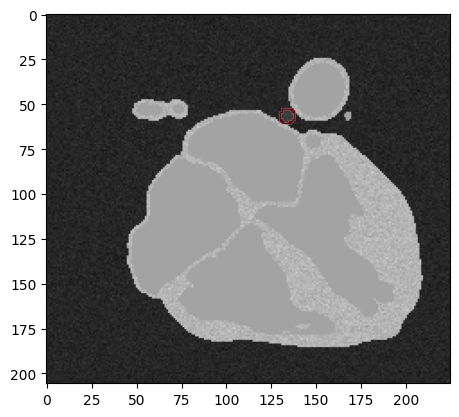

In [5]:
index = 100
plt.imshow(test[0, :, :, index], cmap="gray", vmin=1450, vmax=1650)
plt.imshow(
    body_mask[:, :, index], alpha=(body_mask[:, :, index] > 0) * 0.9, cmap="Reds"
)

# Set up simulation

### Test

In [56]:
num_transducers = 10000     # 1000, 3000
transducers = [
    transducer.Focused(
        max_frequency=0.5e6,   # changed, 0.8e6
        elements=128,
        width=20e-3,
        height=20e-3,
        sensor_sampling_scheme="not_centroid",
        sweep=np.pi / 2,    # np.pi / 2,
        ray_num=24,    # changed, 64
        imaging_ndims=2,
        focus_azimuth=100e-3,
        focus_elevation=150e-3,
        cycles=3,
    )
    for i in range(num_transducers)
]


for t in transducers:
    t.make_sensor_coords(test_phantom.baseline[0])

test_transducer_set = transducer_set.TransducerSet(transducers, seed=8888)


In [57]:
canonical_views = []

# apical 4 chamber
transform1 = geometry.Transform([-np.pi * 0.75, 0, 0], [0, 0, 0])
transform2 = geometry.Transform([0, -np.pi / 2 * 0.1, 0], [0, 0, 0])
transform3 = geometry.Transform([0, 0, 0], [0, 0, 0])
transform = transform1 * transform2 * transform3
position = [-0.15, -0.01, -0.05]
transform.translation = (transform1 * transform2).apply_to_point(
    position, inverse=False
)
canonical_views.append(transform)

# apical 2 chamber
transform1 = geometry.Transform([-np.pi * 0.75, 0, 0], [0, 0, 0])
transform2 = geometry.Transform([0, -np.pi / 2 * 0.1, 0], [0, 0, 0])
transform3 = geometry.Transform([0, 0, -np.pi / 2], [0, 0, 0])
transform = transform1 * transform2 * transform3
position = [-0.15, -0.01, -0.05]
transform.translation = (transform1 * transform2).apply_to_point(
    position, inverse=False
)
canonical_views.append(transform)

# parasternal shout axis papillary
transform1 = geometry.Transform([-np.pi * 0.8, 0, 0], [0, 0, 0])
transform2 = geometry.Transform([0, np.pi / 2 * 0.7, 0], [0, 0, 0])
transform3 = geometry.Transform([-np.pi * 0.15, 0, -np.pi / 2 * 0.3], [0, 0, 0])
transform = transform1 * transform2 * transform3
position = np.array([0.095, 0.04, 0.04])
transform.translation = position
canonical_views.append(transform)
# parasternal short axis mitral
transform1 = geometry.Transform([-3.01825409, 0.87793401, -0.87338513], [0, 0, 0])
transform2 = geometry.Transform([0, 0, 0], [0, 0, 0])
transform3 = geometry.Transform([0, 0, 0], [0, 0, 0])
transform = transform1 * transform2 * transform3
position = np.array([0.09, 0.03, 0.056])
transform.translation = position
canonical_views.append(transform)

# parasternal long axis
transform1 = geometry.Transform([-3.14, 0.95, -2.51], [0, 0, 0])
transform2 = geometry.Transform([-0.2, 0, 0], [0, 0, 0])
transform3 = geometry.Transform([0, 0.04, 0], [0, 0, 0])
transform = transform1 * transform2 * transform3
position = np.array([0.09, 0.025, 0.045])
transform.translation = position
canonical_views.append(transform)

# subcostal 4 chamber
transform1 = geometry.Transform([3, -0.75, 0], [0, 0, 0])
transform2 = geometry.Transform([0, 0, 0], [0, 0, 0])
transform3 = geometry.Transform([0, 0, 0], [0, 0, 0])
transform = transform1 * transform2 * transform3
position = np.array([0.10, 0, -0.15])
transform.translation = position
canonical_views.append(transform)

In [58]:
def add_random_rotation_noise(euler, roll_noise_deg=180, yaw_noise_deg=25, pitch_noise_deg=25):

    yaw, pitch, roll = euler

    # Roll noise uniformly from -180° to +180°
    r_noise_deg = np.random.normal(0, roll_noise_deg)
    r_noise_rad = np.deg2rad(r_noise_deg)
    roll_noisy = roll + r_noise_rad

    # Yaw noise uniformly from -25° to +25°
    y_noise_deg = np.random.normal(0, yaw_noise_deg)
    y_noise_rad = np.deg2rad(y_noise_deg)
    yaw_noisy = yaw + y_noise_rad

    # Pitch noise uniformly from -25° to +25°
    p_noise_deg = np.random.normal(0, pitch_noise_deg)
    p_noise_rad = np.deg2rad(p_noise_deg)
    pitch_noisy = pitch + p_noise_rad

    return [yaw_noisy, pitch_noisy, roll_noisy]

def add_random_position_noise(position, x_noise_range=0.01, y_noise_range=0.05, z_noise_range=0.05):
    x_noise = np.random.normal(0, x_noise_range)
    y_noise = np.random.normal(0, y_noise_range)
    z_noise = np.random.normal(0, z_noise_range)
    return position + np.array([x_noise, y_noise, z_noise])

def noise_transform(transform):
    euler = transform.rotation.as_euler('ZYX', degrees=False)
    euler_noisy = add_random_rotation_noise(euler, pitch_noise_deg=25)
    position = add_random_position_noise(transform.translation)
    return geometry.Transform(euler_noisy, position)
    

In [59]:
for i in range(num_transducers):
    transform = canonical_views[i%len(canonical_views)]
    noisy_transform = noise_transform(transform)
    test_transducer_set.assign_pose(i, noisy_transform)

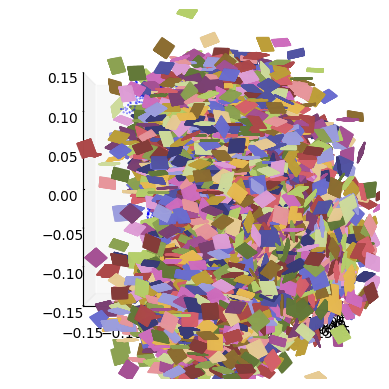

In [51]:
# test plot
# points = np.array((o3d.io.read_triangle_mesh(f"{parent}/assets/cardiac_TEE_phantom/02_myocardium.obj")).sample_points_uniformly(5000).points)
points = np.array(
    (o3d.io.read_triangle_mesh(f"/{parent}/assets/cardiac_TEE_phantom/01_bloodpool.obj"))
    .sample_points_uniformly(8000)
    .points
)

# test_transducer_set.plot_transducer_coords(
#     scale=0.15, phantom_coords=points, view=(90, 0)
# )
ax = test_transducer_set.plot_transducer_coords(
    scale=0.15, phantom_coords=points, view=(0, 0)
)
# test_transducer_set.plot_transducer_coords(
#     scale=0.15, phantom_coords=points, view=(0, 90)
# )

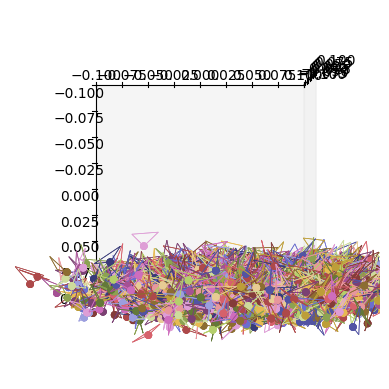

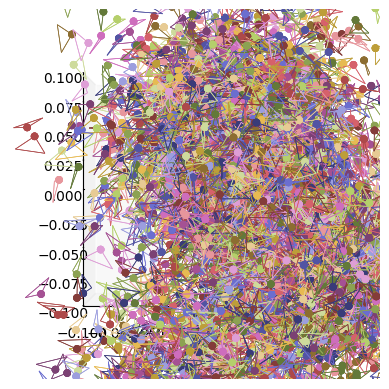

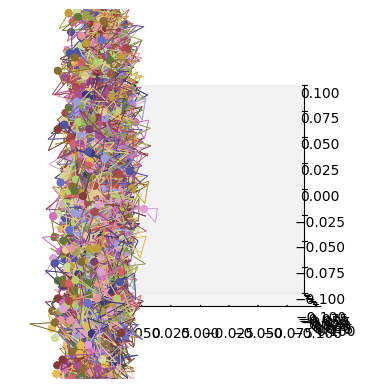

In [52]:
test_transducer_set.plot_transducer_fovs(scale = 0.1, view=(90, 0))
test_transducer_set.plot_transducer_fovs(scale = 0.1, view=(0, 0))
test_transducer_set.plot_transducer_fovs(scale = 0.1, view=(0, 90))

### Original Code

In [60]:
test_sensor = sensor.Sensor(
    transducer_set=test_transducer_set, aperture_type="transmit_as_receive"
)

In [61]:
simprops = simulation.SimProperties(
    grid_size=(200e-3, 25e-3, 25e-3),
    voxel_size=(0.5e-3, 0.5e-3, 0.5e-3),
    PML_size=(16, 16, 16),
    PML_alpha=2,
    t_end=12e-5,  # [s]
    bona=6,  # parameter b/a determining degree of nonlinear acoustic effects
    alpha_coeff=0.5,  # [dB/(MHz^y cm)]
    alpha_power=1.5,
)

In [62]:
test_experiment = experiment.Experiment(
    simulation_path=f"TTE_10k_fast_gaussian",
    sim_properties=simprops,
    phantom=test_phantom,
    transducer_set=test_transducer_set,
    sensor=test_sensor,
    nodes=1,
    results=None,
    indices=None,
    workers=4,
    additional_keys=[],
)

test_experiment.save()

workers is the number of simulations being prepared simultaneously on a single gpu node. Having many workers is RAM intensive and may not decrease overall runtime


# Run Simulation

In [ ]:
# test_experiment = experiment.Experiment.load(f"TTE_5k_fast")
# test_experiment.run(dry=True)

Number of simulation results (0) is less than the expected number of simulation results (120000), are you sure the simulation finished running?


In [18]:
test_experiment.run(repeat=True)

running with 4 workers

preparation for sim    0 completed in  5.30 seconds
preparation for sim 40000 completed in  5.32 seconds
preparation for sim    1 completed in 12.09 seconds
preparation for sim 40001 completed in 11.90 seconds
simulation             0 completed in  4.80 seconds
simulation          40000 completed in  4.79 seconds
preparation for sim 80000 completed in  5.93 seconds
preparation for sim    2 completed in  5.67 seconds
preparation for sim 40002 completed in  6.52 seconds
simulation             1 completed in  4.68 seconds
simulation          40001 completed in  4.85 seconds
preparation for sim    3 completed in  5.52 seconds
simulation          80000 completed in  4.69 seconds
preparation for sim 80001 completed in  5.40 seconds
preparation for sim 40003 completed in  5.42 seconds
simulation             2 completed in  4.83 seconds
simulation          40002 completed in  4.70 seconds
preparation for sim 80002 completed in  5.57 seconds
preparation for sim 40004 com

Process run:
Traceback (most recent call last):
  File "/home/trevor/miniconda3/envs/musik/lib/python3.12/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/home/trevor/miniconda3/envs/musik/lib/python3.12/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/home/trevor/repos/MUSiK/musik/experiment.py", line 336, in run_worker
    simulation = queue.get(False)
                 ^^^^^^^^^^^^^^^^
  File "/home/trevor/miniconda3/envs/musik/lib/python3.12/multiprocessing/queues.py", line 117, in get
    res = self._recv_bytes()
          ^^^^^^^^^^^^^^^^^^
  File "/home/trevor/miniconda3/envs/musik/lib/python3.12/multiprocessing/connection.py", line 216, in recv_bytes
    buf = self._recv_bytes(maxlength)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/trevor/miniconda3/envs/musik/lib/python3.12/multiprocessing/connection.py", line 437, in _recv_bytes
    return self._recv(size)
           ^^^^^^^^^^^^^^^^
  File 

KeyboardInterrupt: 

# Reconstruction

In [ ]:
test_experiment.add_results()

In [ ]:
test_reconstruction = reconstruction.DAS(experiment=test_experiment)

In [ ]:
signals = test_reconstruction.get_signals(
    dimensions=2, matsize=512, downsample=1, workers=16, tgc=10
)

100%|██████████| 1/1 [00:00<00:00,  1.41it/s]


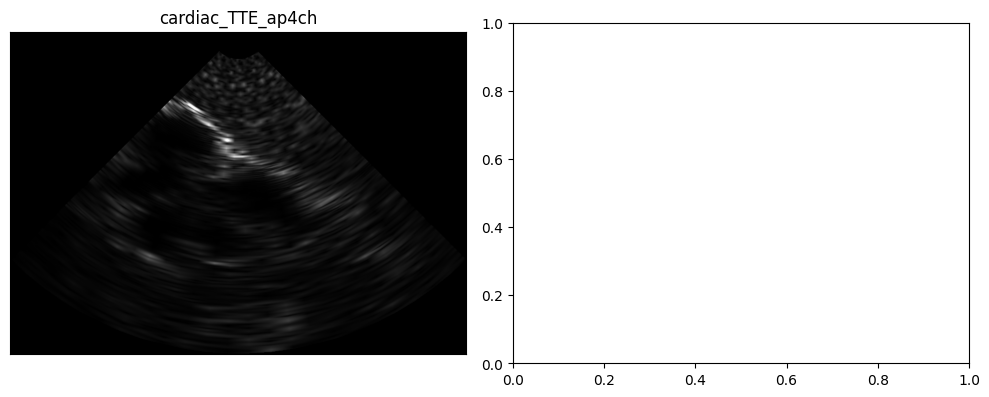

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))   # 1 row, 2 columns

# --- Image 1: apical 4-chamber ---
axes[0].imshow(signals[0][:, ::-1], vmin=0, vmax=100000, cmap="gray")
axes[0].set_title("cardiac_TTE_ap4ch")
axes[0].set_facecolor("black")
axes[0].set_xticks([])
axes[0].set_yticks([])

# # --- Image 2: apical 2-chamber ---
# axes[1].imshow(signals[1][:, ::-1], vmin=0, vmax=100000, cmap="gray")
# axes[1].set_title("cardiac_TTE_ap2ch")
# axes[1].set_facecolor("black")
# axes[1].set_xticks([])
# axes[1].set_yticks([])

plt.tight_layout()
plt.show()

# plt.imshow(signals[2][:, ::-1], vmin=0, vmax=100000, cmap="gray")
# plt.gca().set_facecolor("black")
# plt.gca().set_xticks([])
# plt.gca().set_yticks([])
# plt.savefig(
#     "cardiac_TTE_parasternal_sax_midpap_2MHz.png",
#     bbox_inches="tight",
#     pad_inches=0,
#     dpi=300,
# )
# plt.title("cardiac_TTE_parasternal_sax_midpap")
# plt.show()

# plt.imshow(signals[3][:, ::-1], vmin=0, vmax=100000, cmap="gray")
# plt.gca().set_facecolor("black")
# plt.gca().set_xticks([])
# plt.gca().set_yticks([])
# plt.savefig(
#     "cardiac_TTE_parasternal_sax_mitral_2MHz.png",
#     bbox_inches="tight",
#     pad_inches=0,
#     dpi=300,
# )

# plt.imshow(signals[4][:, ::-1], vmin=0, vmax=100000, cmap="gray")
# plt.gca().set_facecolor("black")
# plt.gca().set_xticks([])
# plt.gca().set_yticks([])
# plt.savefig(
#     "cardiac_TTE_parasternal_lax_2MHz.png", bbox_inches="tight", pad_inches=0, dpi=300
# )

# plt.imshow(signals[5][:, ::-1], vmin=0, vmax=100000, cmap="gray")
# plt.gca().set_facecolor("black")
# plt.gca().set_xticks([])
# plt.gca().set_yticks([])
# plt.savefig(
#     "cardiac_TTE_subcostal_4ch_2MHz.png", bbox_inches="tight", pad_inches=0, dpi=300
# )

In [3]:
test_experiment.transducer_set[0]

(<musik.transducer.Focused at 0x73eb5f4f9760>,
 Transform(rotation=Rotation.from_matrix(array([[-0.5491799 , -0.53662858, -0.64064906],
                             [-0.08486934,  0.79844705, -0.59605327],
                             [ 0.83138357, -0.27296901, -0.48403438]])), translation=array([ 0.10365597, -0.00953752, -0.11152892]), from_matrix=False, about_axis=False, intrinsic=True, ordering=None))

In [5]:
geometry.Transform(np.array([0, 0, 0]), np.array([0, 0, 0]))

Transform(rotation=Rotation.from_matrix(array([[1., 0., 0.],
                            [0., 1., 0.],
                            [0., 0., 1.]])), translation=array([0, 0, 0]), from_matrix=False, about_axis=False, intrinsic=True, ordering=None)

In [13]:
positions = []

# random position
# pos = rand_position_box(0.08, 0.11, -0.1, 0.12, -0.16, 0.15)
rand_position_box(0.09, 0.10, -0.08, 0.10, -0.14, 0.13)
positions.append(pos)

transform = make_transform_facing_origin(pos)
print(transform)

Transform(rotation=Rotation.from_matrix(array([[-0.53369566, -0.76623884,  0.35783653],
                            [-0.84565101,  0.4868414 , -0.21876886],
                            [-0.00658044, -0.41936081, -0.90779579]])), translation=array([0.09398838, 0.0720517 , 0.07024449]), from_matrix=False, about_axis=False, intrinsic=True, ordering=None)
